# Example 1: Landau Zener problem

Authors: C. Ventura-Meinersen and D. Fernandez-Fernandez

Below we import the necesary libraries for this example file:

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from tqdm.auto import tqdm

import geodesiq as gq

# Landau-Zener problem

In this example, we tackle the Landau-Zener (LZ) problem, which is the fundamental problem in optimal state transfer.  The LZ problem can be modelled by a control parameter $z(t)$ and a coupling $x$, which determines the size of the anti-crossing at $z=0$, and can be modelled as follows
$$ \hat{H}[z(t)]=z(t)\sigma_z+x\,\sigma_x=\begin{pmatrix} z(t) & x \\ x & -z(t) \end{pmatrix}$$
In particular, we aim at optimizing the state transfer protocol from $z(0)<0$ to $z(t_\text{f})>0$, where we either want to minimize or maximize the probability of jumping to the nearby energy eigenstate by solving for an optimal pulse shape of the control parameter $z(t)$. We can define the Landau-Zener Hamiltonian and solve it using `solve_problem()` method of the `geodesiq.Hamiltonian()` class. Here, we wish to optimize adiabatic state transfer (minimizing the probability to excite the higher energy state). We first setup the problem:

In [3]:
# ----- Define Hamiltonian -----
def ham(z, x):
    return np.array([[z, x], [x, -z]])


hamiltonian = gq.Hamiltonian(ham)

# ----- Set system and control parameters -----
alpha, beta = 2, 2
x = 1
z0, zf = -10, 10

hamiltonian.set_parameters(x=x)
hamiltonian.set_control(control_name='z', pulse_initial=z0, pulse_final=zf, initial_state=0, alpha=alpha, beta=beta)

By inspecting some details from the Hamiltonian class, we can establish the basic internal parameters of the class:

In [5]:
hamiltonian.print_summary()

------------------ Hamiltonian Control Summary ------------------
Hamiltonian: ✅ set
Partial Hamiltonian: ❌ not set
Hamiltonian parameters: x: 1
Control name → z
Pulse initial → -10
Pulse final → 10
Initial state index → 0
Final state index → 0
(Alpha, Beta) → (2, 2)
(Diabatic Alpha, Diabatic Beta) → (❌ not set, ❌ not set)
Eigenproblem solved → ❌ no
Metric computed → ❌ no
ODE solved → ❌ no
---------------------------------------------------------------


We can also show the energy spectrum to get a better intuition of the problem at hand:

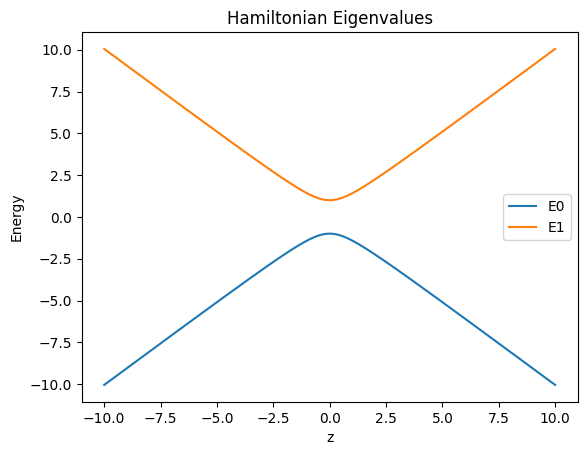

In [6]:
hamiltonian.plot_eigenvalues();

Finally we can solve for the optimal pulse shape $z(t)$ and plot it using the `synthesize_pulse()` method and calling `plot_pulse()`

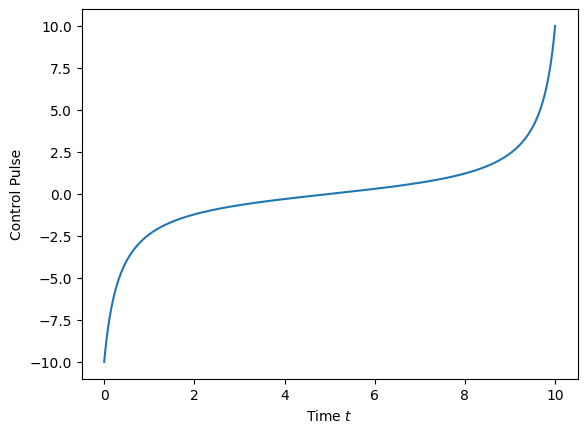

In [7]:
# ----- Solve for optimal pulse -----
hamiltonian.solve_problem(pulse_accuracy=int(1000))

pulse = hamiltonian.synthesize_pulse(duration=10)
pulse.plot_pulse();

Intuitively the pulse tries to minimize the speed at which we traverse the anti-crossing. We can also check the resulting time dynamics with the `Dynamics()` subclass.

# Time dynamics

The state transfer fidelity can be achieved by providing a total pulse time (`duration` variable) and calling the respective function `state_fidelity()`, which also accepts collapse operators to solve the Lindblad equation

In [8]:
dynamics = gq.Dynamics(duration=100, hamiltonian=hamiltonian)

fidelity = dynamics.state_fidelity(c_ops=[])
fidelity_noisy = dynamics.state_fidelity(c_ops=[qt.sigmaz()]) # Added dephasing T2=1
print(fidelity, fidelity_noisy)

0.9999996556418919 0.5000000001118995


These functionalities can of course be mixed together to perform sweeps. Here we sweep through possible total pulse times for the geometric ($\alpha=2,\beta=2$) and FAQUAD ($\alpha=4,\beta=2$) pulsing schemes. 

In [16]:
def fidelity_vs_time(durations, hamiltonian, alpha=2, beta=2):
    hamiltonian.set_control(alpha=alpha, beta=beta)
    hamiltonian.solve_problem(pulse_accuracy=int(1000))

    fidelities = []
    for duration in tqdm(durations):
        dynamics = gq.Dynamics(duration=duration, hamiltonian=hamiltonian)
        fidelities.append(dynamics.state_fidelity())

    return np.array(fidelities)


# Run the fidelity sweep for FAQUAD and geometric pulses
durations = np.linspace(0, 10, 200)
fidelities_geometric = fidelity_vs_time(durations, hamiltonian, alpha=2, beta=2)
fidelities_faquad = fidelity_vs_time(durations, hamiltonian, alpha=4, beta=2)

100%|██████████| 200/200 [00:04<00:00, 41.70it/s]


Finally, we plot the resulting infidelities $1-\mathcal{F}$ for the two methods and see that for longer total pulse times, the error from nonadiabatic transfer is reduced

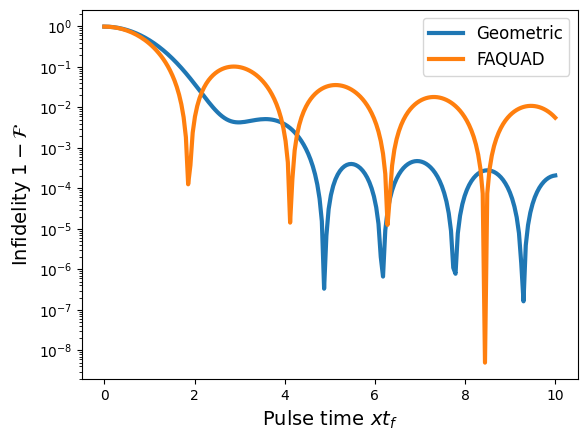

In [17]:
plt.plot(durations, 1 - fidelities_geometric, label='Geometric', lw=3)
plt.plot(durations, 1 - fidelities_faquad, label='FAQUAD', lw=3)
plt.yscale('log')
plt.ylabel(r'Infidelity $1-\mathcal{F}$', fontsize=14)
plt.xlabel('Pulse time $x t_f$', fontsize=14)
plt.legend(fontsize=12)
plt.show()

Finally, even though we optimize for state transfer, we can also check what the resulting use is for the implementation of a unitary. Here we check what the overlap is with the $X$ gate:

In [13]:
gate_fid = gq.Dynamics(duration=50, hamiltonian=hamiltonian).average_gate_fidelity(target_gate=qt.sigmax())
print('Average gate fidelity (at t=tf): ', gate_fid[-1])

Average gate fidelity (at t=tf):  0.977891048276598


About

In [9]:
gq.about()

--------------------------------------------------
geodesiq Information
--------------------------------------------------
geodesiq version: 0.1.0
Python version:    3.10.16 (cpython)
Operating System:  Linux (5.15.0-157-generic, x86_64)

Core Dependencies:
  numpy          : 2.2.6
  scipy          : 1.15.3
--------------------------------------------------


Please cite geodesiq in your publication:
Your Citation Information Here
